In [1]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import GridSearchCV
from scipy import optimize

0.044812744898108034 0.0627254889057005
0.017912744007592463
256.79628958073846


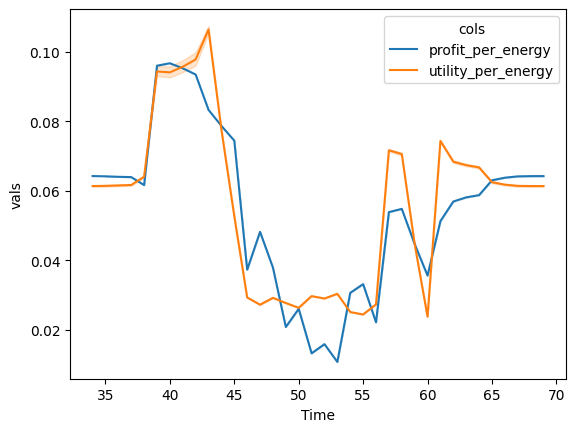

In [5]:
data = pd.read_excel("./data/input_data.xlsx")
data.set_index(["Time","ID"],inplace=True)
data["deposited_money"]=data["demand"]*data["buy_price"]

# define price function
def price_function(X, Y, K_upper, K_lower, theta, B):
    ratio = Y/X
    return K_upper - (K_upper - K_lower) / (1 + np.exp(-B * (ratio - theta)))

    
def calculate_returns(data,midpoint,steepness):
    c = data.copy()
    out = pd.DataFrame(columns=["Time","k_lower","k_upper","sum_energy","sum_money","price","total_affordable_energy","sum_sold_energy","total_demand"])
    for i in range(1,97):
        slice = c.xs(i)
        k_lower= slice["sell_price"].mean()
        k_upper = slice["buy_price"].mean()
        sum_energy = slice["surplus"].sum()
        sum_money = slice["deposited_money"].sum()
        total_demand = slice["demand"].sum()
        price = price_function(sum_money,sum_energy,k_upper,k_lower,midpoint,steepness)
        total_affordable_energy= sum_money/price
        sum_sold_energy = min(total_affordable_energy,sum_energy)
        out.loc[i]= {"Time":i,"k_lower":k_lower,"k_upper":k_upper,"sum_energy":sum_energy,"sum_money":sum_money,"price":price,"total_affordable_energy":total_affordable_energy,"sum_sold_energy":sum_sold_energy,"total_demand":total_demand}
        for j,row in slice.iterrows():
            if row.demand > 0:
                received_energy = sum_sold_energy * (row["deposited_money"]/sum_money)
                c.loc[(i,j),"received_energy"] = received_energy
                cost_received_energy = received_energy*price
                c.loc[(i,j),"cost_received_energy"] = cost_received_energy
                remaining_demand = max(row["demand"]-received_energy,0)
                c.loc[(i,j),"remaining_demand"] = remaining_demand
                excess_received_energy = max(received_energy - row["demand"],0)
                c.loc[(i,j),"excess_received_energy"] = excess_received_energy
                utility_per_energy = row.buy_price-price
                cost_per_excess_energy = price- row["sell_price"]
                c.loc[(i,j),"cost_per_excess_energy"] = cost_per_excess_energy
                utility = utility_per_energy*(received_energy-excess_received_energy) - excess_received_energy*cost_per_excess_energy
                utility_per_energy = None if received_energy ==0 else utility/received_energy
                c.loc[(i,j),"utility"] = utility
                c.loc[(i,j),"utility_per_energy"] = utility_per_energy
            else:
                sold_energy = sum_sold_energy*(row.surplus/sum_energy)
                c.loc[(i,j),"sold_energy"] = sold_energy
                received_money = sold_energy*price
                c.loc[(i,j),"received_money"] = received_money
                unsold_energy = max(row.surplus - sold_energy,0)
                c.loc[(i,j),"unsold_energy"] = unsold_energy
                profit_per_energy = price - row["sell_price"]
                c.loc[(i,j),"profit_per_energy"] = profit_per_energy
                profit = sold_energy*profit_per_energy
                c.loc[(i,j),"profit"] = profit 

    return out,c
        

#df = calculate_returns(data,1,1)[["sum_energy","Time","sum_money","total_affordable_energy","sum_sold_energy"]]
#df = df.melt("Time",var_name="cols",value_name="vals")
#sns.lineplot(df,x="Time",y="vals",hue="cols")

out, df = calculate_returns(data,result_optimizier.x[0],result_optimizier.x[1])
#out, df = calculate_returns(data,1,1)
df1 = df.reset_index()[["Time","profit_per_energy","utility_per_energy","profit","utility"]]
out["surplus_demand_ratio"] = out["sum_energy"]/out["sum_money"]
df = df1.melt("Time",var_name="cols",value_name="vals",value_vars=["profit_per_energy","utility_per_energy"])
sns.lineplot(df,x="Time",y="vals",hue="cols",estimator="mean")
print(df1["profit_per_energy"].mean(),df1["utility_per_energy"].mean())
print(abs(df1["profit_per_energy"].mean() - df1["utility_per_energy"].mean()))
print(df1["profit"].sum()+df1["utility"].sum())




    

<Axes: xlabel='Time', ylabel='vals'>

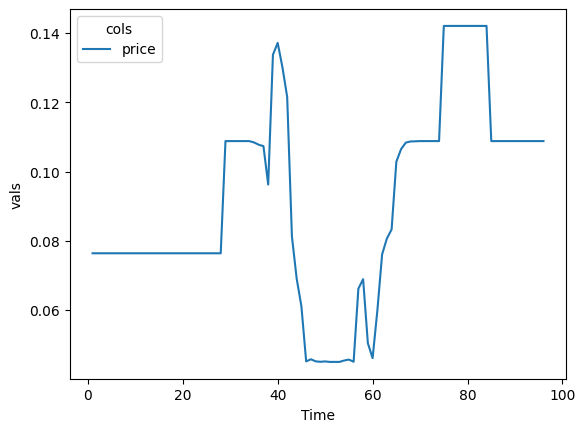

In [30]:
df = out[["Time","price","sum_energy","sum_money","total_demand"]].copy()
df["energy_money_ratio"]= df["sum_energy"]/df["total_demand"]
df = df.melt("Time",value_vars=["price"],var_name="cols",value_name="vals")
sns.lineplot(df,x="Time",y="vals",hue="cols",estimator="mean")
#sns.lineplot(df,x="Time",y="vals",hue="cols",estimator="mean")

<Axes: xlabel='Time', ylabel='surplus_demand_ratio'>

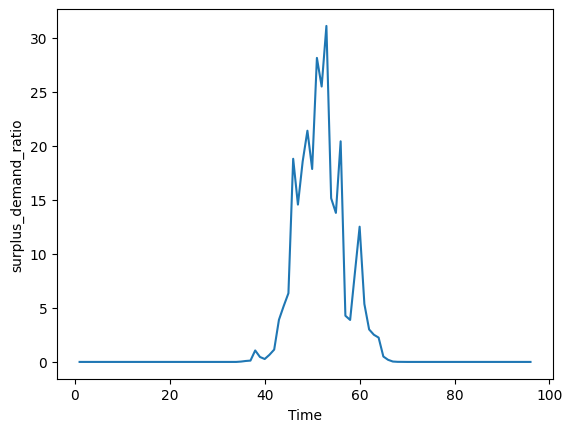

In [44]:
sns.lineplot(out,x="Time",y="surplus_demand_ratio")

In [ ]:
def price_function_sigmoid(x, L=0.08, K=0.34, X_0, B):
    return K - (K - L) / (1 + np.exp(-B * (x - X_0)))

In [2]:
data = pd.read_excel("./data/input_data.xlsx")
data.set_index(["Time","ID"],inplace=True)
data["deposited_money"]=data["demand"]*data["buy_price"]

# define price function
def price_function(X, Y, K_upper, K_lower, theta, B):
    ratio = Y/X
    return K_upper - (K_upper - K_lower) / (1 + np.exp(-B * (ratio - theta)))

    
def optimize_func(params,data):
    midpoint,steepness =params 
    print(params)
    mean_differences = []
    for i in range(1,97):
        utilities=[]
        profits=[]
        slice = data.xs(i)
        k_lower= slice["sell_price"].mean()
        k_upper = slice["buy_price"].mean()
        sum_energy = slice["surplus"].sum()
        sum_money = slice["deposited_money"].sum()
        price = price_function(sum_money,sum_energy,k_upper,k_lower,midpoint,steepness)
        total_affordable_energy= sum_money/price
        sum_sold_energy = min(total_affordable_energy,sum_energy)
        for j,row in slice.iterrows():
            if row.demand > 0:
                received_energy = sum_sold_energy * (row["deposited_money"]/sum_money)                     
                excess_received_energy = max(received_energy - row["demand"],0)               
                utility_per_energy = row["buy_price"]-price               
                cost_per_excess_energy = price- row["sell_price"]               
                utility = utility_per_energy*(received_energy-excess_received_energy) - excess_received_energy*cost_per_excess_energy
                utility_per_energy = None if received_energy == 0 else utility/received_energy
                utilities.append(utility_per_energy)
            else:
                sold_energy = sum_sold_energy*(row.surplus/sum_energy)               
                profit_per_energy = None if sold_energy== 0 else price - row["sell_price"]
                profit = sold_energy*profit_per_energy
                profits.append(profit_per_energy)
        mean_utility = 0 if len(list(filter(None,utilities))) == 0 else sum(list(filter(None,utilities)))/len(list(filter(None,utilities)))
        mean_profit = 0 if len(list(filter(None,profits))) == 0 else sum(list(filter(None,profits)))/len(list(filter(None,profits)))
        mean_differences.append(abs(mean_utility-mean_profit))

    return np.sum(mean_differences)

optimize_func((1,1),data)

(1, 1)


np.float64(2.2851840175275777)

In [4]:
initial_guess = [1, 1]
bnds = [(0, 100), (0, 100)]
result_optimizier = minimize(optimize_func, initial_guess, args=(data),bounds=bnds,method='L-BFGS-B')


[1. 1.]
[1.00000001 1.        ]
[1.         1.00000001]
[0.58480172 0.09976016]
[0.58480173 0.09976016]
[0.58480172 0.09976017]
[0.60733249 0.        ]
[0.6073325 0.       ]
[6.07332488e-01 1.00000000e-08]
[0.59020422 0.07583937]
[0.59020423 0.07583937]
[0.59020422 0.07583938]
[0.58931875 0.07936678]
[0.58931876 0.07936678]
[0.58931875 0.07936679]
[0.58963859 0.07787778]
[0.5896386  0.07787778]
[0.58963859 0.07787779]
[0.59091793 0.07192176]
[0.59091794 0.07192176]
[0.59091793 0.07192177]
[0.58981045 0.07707765]
[0.58981046 0.07707765]
[0.58981045 0.07707766]
[0.58972536 0.07747382]
[0.58972537 0.07747382]
[0.58972536 0.07747383]
[0.58960612 0.07772727]
[0.58960613 0.07772727]
[0.58960612 0.07772728]
[0.5891292  0.07874106]
[0.58912921 0.07874106]
[0.5891292  0.07874107]
[0.58958747 0.07776693]
[0.58958748 0.07776693]
[0.58958747 0.07776694]
[0.58957053 0.07780293]
[0.58957054 0.07780293]
[0.58957053 0.07780294]
[0.58958679 0.07776837]
[0.5895868  0.07776837]
[0.58958679 0.07776838]
[0

In [6]:
result_optimizier.x

array([0.58958658, 0.07776882])

In [33]:
midpoint_values = np.linspace(1,10,num=100)
steepness_values = np.linspace(1,20,num=100)
out= [np.zeros(1000) for row in range(0,len(midpoint_values))]
resbrute = optimize.brute(optimize_func,(slice(0,10,1),slice(0,10,1)),args=(data,),full_output=True)
result = resbrute[0]
result


[0 0]
[0 1]
[0 2]
[0 3]
[0 4]
[0 5]
[0 6]
[0 7]
[0 8]
[0 9]
[1 0]
[1 1]
[1 2]
[1 3]
[1 4]
[1 5]
[1 6]
[1 7]
[1 8]
[1 9]
[2 0]
[2 1]
[2 2]
[2 3]
[2 4]
[2 5]
[2 6]
[2 7]
[2 8]
[2 9]
[3 0]
[3 1]
[3 2]
[3 3]
[3 4]
[3 5]
[3 6]
[3 7]
[3 8]
[3 9]
[4 0]
[4 1]
[4 2]
[4 3]
[4 4]
[4 5]
[4 6]
[4 7]
[4 8]
[4 9]
[5 0]
[5 1]
[5 2]
[5 3]
[5 4]
[5 5]
[5 6]
[5 7]
[5 8]
[5 9]
[6 0]
[6 1]
[6 2]
[6 3]
[6 4]
[6 5]
[6 6]
[6 7]
[6 8]
[6 9]
[7 0]
[7 1]
[7 2]
[7 3]
[7 4]
[7 5]
[7 6]
[7 7]
[7 8]
[7 9]
[8 0]
[8 1]
[8 2]
[8 3]
[8 4]
[8 5]
[8 6]
[8 7]
[8 8]
[8 9]
[9 0]
[9 1]
[9 2]
[9 3]
[9 4]
[9 5]
[9 6]
[9 7]
[9 8]
[9 9]
[0. 0.]
[0.00025 0.     ]
[0.      0.00025]
[-0.00025  0.00025]
[-0.0005    0.000375]
[-0.0005    0.000625]
[-0.00075    0.0009375]
[-0.00125    0.0010625]
[-0.001875    0.00146875]
[-0.002125    0.00203125]
[-0.0029375   0.00285937]
[-0.0040625   0.00339063]
[-0.00571875  0.00461719]
[-0.00678125  0.00600781]
[-0.00923438  0.00827734]
[-0.01201563  0.01003516]
[-0.01655469  0.01362305]
[-0.020070

array([0.36346039, 0.07610037])

(array([0.36346039, 0.07610037]),
 np.float64(0.2853381288602567),
 array([[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
         [4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
         [5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
         [6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
         [7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
         [8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
         [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]],
 
        [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]]),
 array([[0.78761639, 2.10456838, 2.43934949, 2.62490902, 2.75061152,
         2.84183962, 2.91122723, 2.965

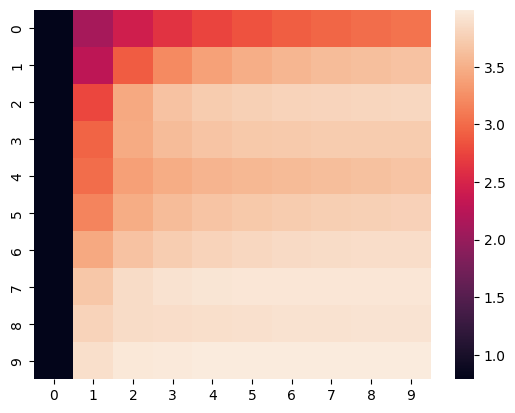

In [34]:
resbrute[3]
sns.heatmap(resbrute[3])
resbrute

In [28]:
result = resbrute[0]
result

array([0.02019452, 5.81534065])

In [201]:
### Optimize parameters
def objective_function(params,data):
    theta,B = params
    total_diff = 0
    k_upper = cycle_data['buy_price'].min()
    k_lower = cycle_data['sell_price'].max()
    for cycle in range(1,97):
        cycle_data = data.xs(cycle)
        buyers = cycle_data[cycle_data["demand"]>0]
        sellers = cycle_data[cycle_data["surplus"] > 0]
        k_upper = cycle_data['buy_price'].min()
        k_lower = cycle_data['sell_price'].max()
        total_money = (cycle_data["demand"]*cycle_data["buy_price"]).sum()
        total_energy = cycle_data["surplus"].sum()
        price = price_function(total_money,total_energy,k_upper,k_lower,theta,B)
        #print(price)
        profits =  calculate_profit(sellers,price,total_money,cycle,data)[1]
        utilities =  calculate_utility(buyers,price,total_energy,cycle,data)[1]
        
        avg_profit = 0 if len(profits) == 0 else sum(profits)/len(profits)
        avg_utility= 0 if len(utilities)==0 else sum(utilities)/len(utilities)
        diff_avg= abs(avg_profit-avg_utility)
        total_diff += diff_avg
        #print(avg_utility)
    #print(total_diff)
    return total_diff

initial_guess = [0.5, 2]
bnds = [(0, 100), (0, 1000)]
result = minimize(objective_function, initial_guess, args=(data),bounds=bnds)

In [18]:
result[0]


NameError: name 'result' is not defined

C:\Users\hmart\AppData\Local\Temp\ipykernel_8952\2295103004.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buyers["deposited_money"] = buyers["demand"]*buyers["buy_price"]
C:\Users\hmart\AppData\Local\Temp\ipykernel_8952\2295103004.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buyers["deposited_money"] = buyers["demand"]*buyers["buy_price"]
C:\Users\hmart\AppData\Local\Temp\ipykernel_8952\2295103004.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

<Axes: >

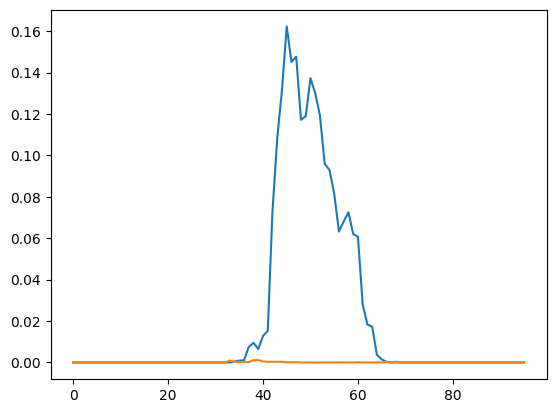

In [ ]:
data = pd.read_excel("./data/input_data.xlsx")
data.set_index(["Time","ID"],inplace=True)
prices=[]
utilities_means=[]
profit_means=[]
for cycle in range(1,97):
        cycle_data = data.xs(cycle)
        buyers = cycle_data[cycle_data["demand"]>0]
        sellers = cycle_data[cycle_data["surplus"] > 0]
        k_upper = cycle_data['buy_price'].min()
        k_lower = cycle_data['sell_price'].max()
        total_money = (cycle_data["demand"]*cycle_data["buy_price"]).sum()
        total_energy = cycle_data["surplus"].sum()
        price = price_function(total_money,total_energy,k_upper,k_lower,result.x[1],result.x[0])
        utilities = calculate_utility(buyers,price,total_energy,cycle,data)[1]
        profits = calculate_profit(sellers,price,total_money,cycle,data)[1]
        avg_profit = 0 if len(profits) == 0 else sum(profits)/len(profits)
        avg_utility= 0 if len(utilities) == 0 else sum(utilities)/len(utilities)
        utilities_means.append(avg_utility)
        profit_means.append(avg_profit)
        prices.append(price)
        
sns.lineplot(utilities_means)
sns.lineplot(profit_means)

<Axes: >

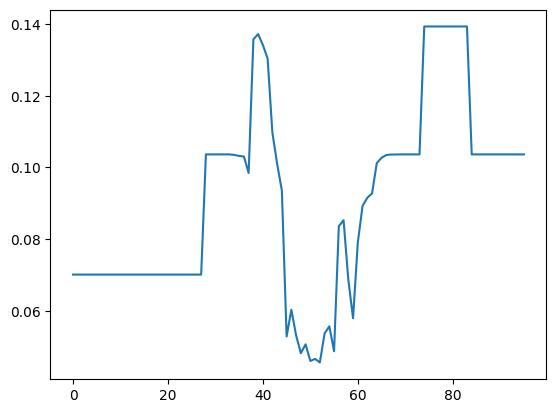

In [148]:
sns.lineplot(prices)

In [55]:
x = data.groupby(by="Time").agg({"demand":"sum"})